# Read data From File

In [ ]:
import os
import re
import numpy as np

def parse_bvh_file(bvh_path):
    """
    Parse a single BVH file to extract:
      - motion_data: shape = (num_frames, num_channels)
      - num_frames
      - frame_time
    """
    with open(bvh_path, 'r') as f:
        lines = f.readlines()

    motion_start_idx = None
    num_frames = None
    frame_time = None

    # 1) Find where "MOTION" starts, and get 'Frames:' / 'Frame Time:' lines
    for i, line in enumerate(lines):
        if line.strip().upper().startswith("MOTION"):
            motion_start_idx = i
        if line.strip().lower().startswith("frames:"):
            parts = line.strip().split()
            num_frames = int(parts[1])  # e.g. "Frames: 803"
        if line.strip().lower().startswith("frame time:"):
            parts = line.strip().split()
            frame_time = float(parts[2])  # e.g. "Frame Time: 0.0111111"

    if motion_start_idx is None or num_frames is None:
        raise ValueError(f"Could not find MOTION or Frames in {bvh_path}.")

    # 2) Motion data lines typically start after "Frame Time:" line
    #    We'll assume those lines are directly after motion_start_idx+3
    motion_data_lines = lines[motion_start_idx + 3 : motion_start_idx + 3 + num_frames]

    all_frames = []
    for line in motion_data_lines:
        # e.g. "-334.665 92.7133 655.436 -2.87978 -0.719654 -118.909 ..."
        parts = line.strip().split()
        floats = list(map(float, parts))
        all_frames.append(floats)

    motion_data = np.array(all_frames, dtype=np.float32)
    return motion_data, num_frames, frame_time

def get_label_from_filename(filename):
    """
    Example: we have filenames like "TVBS01P03R86.bvh".
    We'll map 'P01' -> 0, 'P02' -> 1, 'P03' -> 2
    Adjust or extend for your classes.
    """
    match = re.search(r"P(\d\d)", filename, re.IGNORECASE)
    if not match:
        raise ValueError(f"Could not find a 'PXX' pattern in filename: {filename}")
    pxx = match.group(1)  # e.g. "03"

    if pxx == "01":
        return 0
    elif pxx == "02":
        return 1
    elif pxx == "03":
        return 2
    else:
        raise ValueError(f"Unrecognized 'P{pxx}' in filename: {filename}")

def load_bvh_dataset(folder_path):
    """
    Loads all .bvh files in `folder_path`, parses each for motion data,
    and assigns class labels from the 'PXX' substring in the filename.

    Returns:
      data_list: list of arrays [ (frames1, channels), (frames2, channels), ... ]
      labels:    list of integer labels
      filenames: list of file names
      max_frames: the maximum #frames found across all BVH files
      num_channels: # of channels found (assuming consistent across files)
    """
    data_list = []
    labels = []
    filenames = []

    max_frames = 0
    num_channels = None

    bvh_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.bvh')])
    if not bvh_files:
        raise ValueError("No BVH files found in the specified folder.")

    # First pass: parse each BVH to find #frames, #channels
    #  and keep track of the maximum
    for fname in bvh_files:
        full_path = os.path.join(folder_path, fname)
        motion_data, fcount, ftime = parse_bvh_file(full_path)

        # Update max frames if needed
        if fcount > max_frames:
            max_frames = fcount

        # If we haven't set num_channels yet, do so
        if num_channels is None:
            num_channels = motion_data.shape[1]
        else:
            # Optionally, you can verify that channel count matches
            if motion_data.shape[1] != num_channels:
                raise ValueError(
                    f"Inconsistent channel counts: {fname} has {motion_data.shape[1]}, "
                    f"expected {num_channels} from earlier files."
                )

    # Second pass: parse again (or you could store the data from first pass in memory)
    #  but here we already have the idea, so let's just do it in one pass. We'll store data in a list:
    data_list.clear()  # just to demonstrate the second pass
    for fname in bvh_files:
        full_path = os.path.join(folder_path, fname)
        motion_data, fcount, ftime = parse_bvh_file(full_path)
        label = get_label_from_filename(fname)

        data_list.append(motion_data)
        labels.append(label)
        filenames.append(fname)

    return data_list, labels, filenames, max_frames, num_channels

def block_average_downsample(data, downsample_factor=4):
    """
    data: shape (N, k, T)
      - N: number of samples (e.g., different sequences)
      - k: number of features (e.g., channels)
      - T: original number of time steps

    downsample_factor: integer factor by which we reduce T via block averaging

    Returns:
      downsampled_data of shape (N, k, T_new)
      where T_new = T // downsample_factor
    """

    N, k, T = data.shape
    # Ensure T is a multiple of downsample_factor (or handle leftover carefully)
    T_new = T // downsample_factor

    # Optionally, if T is not divisible, you might discard the last few frames:
    data = data[:, :, :T_new * downsample_factor]

    # Now data.shape is (N, k, T_new * downsample_factor)

    # Reshape to group each block of 'downsample_factor' time steps
    # together so we can average over them.
    # We will add a new 4th dimension of size downsample_factor:
    reshaped = data.reshape(N, k, T_new, downsample_factor)

    # Take the mean along the last dimension (the block dimension).
    downsampled_data = reshaped.mean(axis=3)  # shape => (N, k, T_new)

    return downsampled_data

if __name__ == "__main__":
    folder = "BVH"  # your actual path
    data_list, labels_list, fnames, max_frames, num_channels = load_bvh_dataset(folder)

    print("Number of BVH files (N):", len(data_list))
    print("Max frames among all files:", max_frames)
    print("Channel count (should be consistent across files):", num_channels)

    # We'll build a final array: shape = (N, max_frames, num_channels)
    # We'll zero-pad each motion array up to max_frames
    N = len(data_list)

    mymax_frames = 200
    final_data = np.zeros((N, mymax_frames, num_channels), dtype=np.float32)


    final_labels = np.array(labels_list, dtype=np.int64)

    for i, motion_arr in enumerate(data_list):
        f = motion_arr.shape[0]  # actual frames for this file
        copy_len = min(f, mymax_frames)
        final_data[i, :copy_len, :] = motion_arr[:copy_len, :]

    final_data = np.transpose(final_data, (0, 2, 1))  # => shape (N, channels, T)
    final_data = block_average_downsample(final_data, downsample_factor=2)
    # now final_data is shape (N, channels, T_new)

    # If you still want it back in (N, T, channels), transpose again
    #final_data = np.transpose(final_data, (0, 2, 1))  # => shape (N, T_new, channels)

    print("final_data.shape =", final_data.shape)   # (N, max_frames, num_channels)
    print("final_labels.shape =", final_labels.shape)  # (N,)
    print("Some labels:", final_labels[:100])
    print("Some filenames:", fnames[:100])

    # Now final_data is your dataset, with each BVH's motion padded to the largest frame count found.
    # final_labels are the classes extracted from the 'PXX' part of each filename.


Number of BVH files (N): 323
Max frames among all files: 6638
Channel count (should be consistent across files): 390
final_data.shape = (323, 390, 100)
final_labels.shape = (323,)
Some labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1]
Some filenames: ['TVBS01P01R01.bvh', 'TVBS01P01R02.bvh', 'TVBS01P01R03.bvh', 'TVBS01P01R04.bvh', 'TVBS01P01R05.bvh', 'TVBS01P01R06.bvh', 'TVBS01P01R07.bvh', 'TVBS01P01R08.bvh', 'TVBS01P01R09.bvh', 'TVBS01P01R10.bvh', 'TVBS01P01R11.bvh', 'TVBS01P01R12.bvh', 'TVBS01P01R13.bvh', 'TVBS01P01R14.bvh', 'TVBS01P01R15.bvh', 'TVBS01P01R16.bvh', 'TVBS01P01R17.bvh', 'TVBS01P01R18.bvh', 'TVBS01P01R19.bvh', 'TVBS01P01R20.bvh', 'TVBS01P01R21.bvh', 'TVBS01P01R22.bvh', 'TVBS01P01R23.bvh', 'TVBS01P01R24.bvh', 'TVBS01P01R25.bvh', 'TVBS01P01R26.bvh', 'TVBS01P01R27.bvh', 'TVBS01P01R28.bvh', 'TVBS01P01R29.bvh', 'TVBS0

# Custom Vit

In [ ]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as T
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import balanced_accuracy_score, f1_score

# ----------------------------------------------------------------
# 1) Dataset that randomly masks data on the fly
# ----------------------------------------------------------------
class RandomUpToPpresentAugDataset(Dataset):
    """
    data_np: shape (N, 829, 390)
    labels_np: shape (N,)
    p_present: fraction of rows that *may* remain at most
    augment_factor: how many random variants per original sample
    This yields a total length = N * augment_factor.
    For each augmented index, we:
       - pick the base sample index
       - pick how many rows to keep [0.. p_present*Nrows]
       - pick which rows
       - zero out others
       - replicate data+mask => 6 channels
       - resize to (224,224)
    """

    def __init__(self, data_np, labels_np, p_present=0.8, augment_factor=5):
        assert len(data_np) == len(labels_np)
        self.data = data_np
        self.labels = labels_np
        self.N_orig = len(data_np)
        self.p_present = p_present
        self.augment_factor = augment_factor

        self.x_dim = data_np.shape[1]  # 829
        self.y_dim = data_np.shape[2]  # 390

        # total length
        self.N = self.N_orig * self.augment_factor

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        # 1) figure out which original sample
        base_idx = idx // self.augment_factor  # integer division
        data_2d = self.data[base_idx]
        label = self.labels[base_idx]

        # 2) pick how many rows we can keep
        nRows = data_2d.shape[0]  # 829
        maxKeep = int(round(self.p_present * nRows))
        numKeep = random.randint(0, maxKeep)

        # 3) pick exactly numKeep rows to keep
        kept_rows = random.sample(range(nRows), numKeep)
        row_mask = np.zeros(nRows, dtype=np.float32)
        row_mask[kept_rows] = 1.0

        # replicate row_mask
        mask_2d = np.repeat(row_mask[:, None], data_2d.shape[1], axis=1)

        # zero out
        data_masked = data_2d * mask_2d

        # 4) create data+mask
        data_t = torch.from_numpy(data_masked).float()
        mask_t = torch.from_numpy(mask_2d).float()

        # replicate each => (3,390,829)
        data_3ch = data_t.unsqueeze(0).expand(3, -1, -1)
        mask_3ch = mask_t.unsqueeze(0).expand(3, -1, -1)
        six_ch = torch.cat([data_3ch, mask_3ch], dim=0)

        # resize => (6,224,224)
        mini_batch = six_ch.unsqueeze(0)
        resized = F.interpolate(mini_batch, size=(224, 224), mode='bilinear', align_corners=False)
        resized_6ch = resized.squeeze(0)

        return resized_6ch, int(label)


# ----------------------------------------------------------------
# 2) Custom Vision Transformer Implementation
# ----------------------------------------------------------------
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = img_size // patch_size
        self.num_patches = self.grid_size * self.grid_size

        self.proj = nn.Conv2d(
            in_channels=in_chans,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


class Attention(nn.Module):
    def __init__(self, dim, num_heads, qkv_bias=False, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, qkv_bias=False, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(
            dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=drop
        )
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(in_features=dim, hidden_features=int(dim * mlp_ratio), drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=224,
        patch_size=16,
        in_chans=3,
        num_classes=1000,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=True,
        drop_rate=0.0,
        attn_drop_rate=0.0
    ):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim = embed_dim

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim
        )
        self.num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate
            )
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=1e-6)
        nn.init.normal_(self.pos_embed, std=1e-6)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.normal_(self.head.bias, std=1e-6)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embed[:, :x.size(1), :]
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_token_final = x[:, 0]
        x = self.head(cls_token_final)
        return x


# ----------------------------------------------------------------
# 3) The main training function
# ----------------------------------------------------------------

def save_checkpoint(model, optimizer, epoch, filepath="vit_checkpoint.pth"):
    directory = os.path.dirname(filepath)
    if directory and not os.path.exists(directory):
        os.makedirs(directory)

    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch
    }, filepath)
    print(f"Checkpoint saved to: {filepath}")


def load_or_create_model_optimizer(VisionTransformerClass,
                                   filepath="vit_checkpoint.pth",
                                   device="cpu",
                                   lr=1e-5,
                                   **model_kwargs):
    model = VisionTransformerClass(**model_kwargs).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    if os.path.isfile(filepath):
        print(f"Found checkpoint at {filepath}. Loading...")
        checkpoint = torch.load(filepath, map_location=device)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint.get('epoch', 0)

        print(f"Loaded model and optimizer from '{filepath}', epoch {start_epoch}")
    else:
        print(f"No checkpoint found at {filepath}. Creating a new model/optimizer.")
        start_epoch = 0

    model.eval()
    return model, optimizer, start_epoch


def main():
    N = 100

    dataset = RandomUpToPpresentAugDataset(
        final_data.copy(),
        final_labels.copy(),
        p_present=0.2,
        augment_factor=100
    )

    n_total = len(dataset)
    n_train = int(0.8 * n_total)
    n_val = n_total - n_train

    g = torch.Generator().manual_seed(42)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=g)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    global val_loader
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_kwargs = dict(
        img_size=224,
        patch_size=16,
        in_chans=6,
        num_classes=3,
        embed_dim=768,
        depth=12,
        num_heads=12
    )

    checkpoint_path = "checkpoints/testVit2.pth"

    global vit_model
    vit_model, optimizer, start_epoch = load_or_create_model_optimizer(
        VisionTransformer,
        filepath=checkpoint_path,
        device=device,
        lr=1e-5,
        **model_kwargs
    )

    writer = SummaryWriter(log_dir="runs/testVit2")

    criterion = nn.CrossEntropyLoss()
    total_epochs = 305

    for epoch in range(start_epoch, total_epochs):
        vit_model.train()
        total_loss, total_correct = 0.0, 0
        train_targets, train_preds = [], []

        for (imgs, labels) in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = vit_model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()

            train_targets.extend(labels.detach().cpu().numpy())
            train_preds.extend(preds.detach().cpu().numpy())

        train_size = len(train_loader.dataset)
        train_loss = total_loss / train_size
        train_acc = total_correct / train_size
        train_bal_acc = balanced_accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro")

        vit_model.eval()
        val_loss_sum, val_correct = 0.0, 0
        val_targets, val_preds = [], []

        with torch.no_grad():
            for (imgs, labels) in val_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = vit_model(imgs)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()

                val_targets.extend(labels.detach().cpu().numpy())
                val_preds.extend(preds.detach().cpu().numpy())

        val_size = len(val_loader.dataset)
        val_loss = val_loss_sum / val_size
        val_acc = val_correct / val_size
        val_bal_acc = balanced_accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro")

        print(f"Epoch [{epoch+1}/{total_epochs}] "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} || "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f}")

        writer.add_scalar("Loss/Train", train_loss, epoch + 1)
        writer.add_scalar("Loss/Validation", val_loss, epoch + 1)
        writer.add_scalar("BalancedAccuracy/Train", train_bal_acc, epoch + 1)
        writer.add_scalar("BalancedAccuracy/Validation", val_bal_acc, epoch + 1)
        writer.add_scalar("F1_Macro/Train", train_f1, epoch + 1)
        writer.add_scalar("F1_Macro/Validation", val_f1, epoch + 1)

        save_checkpoint(vit_model, optimizer, epoch + 1, filepath="checkpoints/testVit2-2Epochs.pth")

    writer.close()
    print("Training complete.")
    return vit_model


if __name__ == "__main__":
    vit_model = main()

Found checkpoint at checkpoints/testVit2.pth. Loading...
Loaded model and optimizer from 'checkpoints/testVit2.pth', epoch 300
Epoch [301/305] Train Loss: 0.1060, Acc: 0.949 || Val Loss: 0.1019, Acc: 0.950
Checkpoint saved to: checkpoints/testVit2-2Epochs.pth


KeyboardInterrupt: 

# Genetic Optimization

[4.9868760e-01 2.8810443e-04 5.0102425e-01]


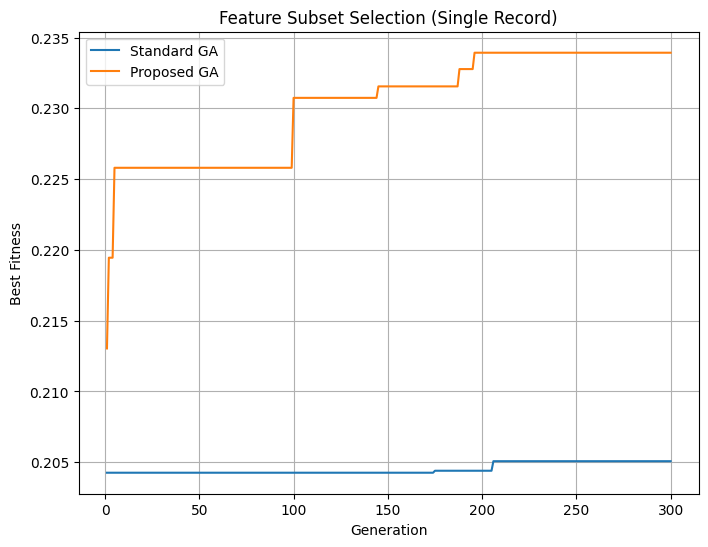

Standard GA:
  Best Fitness: 0.20507774
  Selected Features: 31
  Probability Distribution with Best Chromosome: [0.40764916 0.07267787 0.51967293]
Proposed GA:
  Best Fitness: 0.23392655
  Selected Features: 24
  Probability Distribution with Best Chromosome: [0.37898842 0.16230509 0.4587065 ]


In [ ]:
import random
import copy
import math
import matplotlib.pyplot as plt
import sys

################################################
# A) Single-Record Reference Probability
################################################

import torch
import torch.nn.functional as F
import numpy as np

################################################
# A) Single-Record Reference Probability
################################################

def get_reference_probs_for_single_record(model, single_sample):
    """
    For your single record (with ALL features), run it through the trained model
    and return the probability distribution (1D array of shape = (#classes,)).

    Assumes:
      - single_sample is a numpy array of shape (829, 390).
      - You replicate data & an all-ones mask into 6 channels,
        then resize to (224,224), as in your dataset augmentation.
    """
    # Convert to torch
    data_2d = torch.from_numpy(single_sample).float()  # shape (390,829)
    # Full mask (all features => 1)
    mask_2d = torch.ones_like(data_2d)                 # shape (390,829)

    # Replicate each into 3 channels => (3,390,829)
    data_3ch = data_2d.unsqueeze(0).expand(3, -1, -1)
    mask_3ch = mask_2d.unsqueeze(0).expand(3, -1, -1)

    # Concatenate => (6,390,829)
    six_ch = torch.cat([data_3ch, mask_3ch], dim=0)

    # Add batch dimension => (1,6,390,829)
    six_ch = six_ch.unsqueeze(0)

    # Resize to (1,6,224,224) just like training
    resized = F.interpolate(six_ch, size=(224,224), mode='bilinear', align_corners=False)

    # Move to model's device
    device = next(model.parameters()).device
    resized = resized.to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(resized)         # shape (1, num_classes)
        probs = torch.softmax(logits, dim=1)  # shape (1, num_classes)

    # Return as numpy, shape (num_classes,)
    return probs.squeeze(0).cpu().numpy()


################################################
# B) get_subset_probs for Single-Record
################################################

def get_subset_probs(chrom, model, single_sample):
    """
    chrom          : list/array of length 390  (one bit per ROW)
    single_sample  : numpy (390, 829)
    returns        : numpy (num_classes,)  – soft‑max probabilities
    """
    assert len(chrom) == single_sample.shape[0], \
        "Chromosome length must equal #rows (= 390)."

    device = next(model.parameters()).device

    # ---------- 1. build the masked 2‑D data -----------------------
    data_2d = torch.from_numpy(single_sample).float()          # (390,829)

    row_mask_1d = torch.tensor(chrom, dtype=torch.float32)     # (390,)
    row_mask_2d = row_mask_1d.unsqueeze(1).expand(-1, data_2d.size(1))
    # shape (390,829) – each bit repeated across all 829 columns

    data_masked = data_2d * row_mask_2d                        # zero-out rows

    # ---------- 2. make 6‑channel image ---------------------------
    data_3ch = data_masked.unsqueeze(0).expand(3, -1, -1)      # (3,390,829)
    mask_3ch = row_mask_2d.unsqueeze(0).expand(3, -1, -1)      # (3,390,829)
    six_ch   = torch.cat([data_3ch, mask_3ch], dim=0)          # (6,390,829)

    six_ch = six_ch.unsqueeze(0)                               # (1,6,390,829)
    six_ch = F.interpolate(six_ch,
                           size=(224,224),
                           mode='bilinear',
                           align_corners=False).to(device)

    # ---------- 3. forward pass -----------------------------------
    with torch.no_grad():
        probs = torch.softmax(model(six_ch), dim=1).squeeze(0)  # (num_classes,)

    return probs.cpu().numpy()



################################################
# C) Fitness Function for Single-Record
################################################

def feature_subset_fitness(chrom, reference_probs, model, single_sample, alpha=0.01):
    """
    For a single record, the fitness is:
      - negative cross-entropy between reference_probs and subset_probs
      - plus a penalty for the number of selected features

    reference_probs: shape (#classes,)
    subset_probs: also shape (#classes,)
    """
    subset_probs = get_subset_probs(chrom, model, single_sample)

    # Cross-entropy: CE(reference_probs || subset_probs)
    # cross_entropy = - sum ( p_ref[j] * log(p_subset[j] ) )
    eps = 1e-8
    ce_sum = 0.0
    for j in range(len(reference_probs)):
        p_ref = reference_probs[j]
        p_sub = subset_probs[j] + eps
        ce_sum -= p_ref * math.log(p_sub)

    # Penalty for # of selected features
    #print(ce_sum)
    num_selected = sum(chrom)
    #print(num_selected)
    #print(alpha)
    penalty = alpha * num_selected

    cost = ce_sum + penalty
    fitness = 1/(1 + cost)  # smaller cost => higher fitness
    return fitness


################################################
# D) GA Routines (Same Structure as Before)
################################################

def create_random_population(pop_size, num_features, one_rate):
    """Create random bitmasks of length 'num_features'."""
    population = []
    for _ in range(pop_size):
        chrom = [1 if random.random() < one_rate else 0 for _ in range(num_features)]
        population.append(chrom)
    return population

def standard_ga_single_record(
    gens,
    pop_size,
    num_features,
    one_rate,
    reference_probs,
    model,
    single_sample,
    alpha=0.01,
    p_crossover=0.8,
    mutation_rate=0.01,
    elitism=True,
    elitism_size=1,
    initial_population=None
):
    """
    Standard GA for single-record feature selection:
      - Roulette selection
      - One-point crossover
      - Mutation flips bits
      - Elitism
    Returns (best_history, best_chromosome)
    """

    if initial_population is not None:
        population = copy.deepcopy(initial_population)
    else:
        population = create_random_population(pop_size, num_features, one_rate)

    def roulette_selection(pop, fits):
        total_fit = sum(fits)
        if total_fit == 0:
            return random.choice(pop)
        pick = random.random() * total_fit
        running = 0.0
        for i, individual in enumerate(pop):
            running += fits[i]
            if running >= pick:
                return individual
        return pop[-1]

    def one_point_crossover(p1, p2):
        length = len(p1)
        point = random.randint(1, length - 1)
        c1 = p1[:point] + p2[point:]
        c2 = p2[:point] + p1[point:]
        return c1, c2

    def mutate(chrom):
        for i in range(len(chrom)):
            if random.random() < mutation_rate:
                chrom[i] = 1 - chrom[i]  # flip bit
        return chrom

    best_history = []
    best_chrom_so_far = None
    best_fit_so_far = float('-inf')

    for gen in range(gens):
        # Evaluate population
        fitnesses = [
            feature_subset_fitness(ch, reference_probs, model, single_sample, alpha=alpha)
            for ch in population
        ]
        gen_best = max(fitnesses)
        best_history.append(gen_best)

        if gen_best > best_fit_so_far:
            best_fit_so_far = gen_best
            idx = fitnesses.index(gen_best)
            best_chrom_so_far = population[idx][:]

        # Elitism
        if elitism:
            sorted_pop = sorted(zip(population, fitnesses), key=lambda x: x[1], reverse=True)
            elites = [p for p,f in sorted_pop[:elitism_size]]
        else:
            elites = []

        # Create new population
        new_pop = []
        while len(new_pop) < pop_size - len(elites):
            p1 = roulette_selection(population, fitnesses)
            p2 = roulette_selection(population, fitnesses)

            if random.random() < p_crossover:
                c1, c2 = one_point_crossover(p1, p2)
            else:
                c1, c2 = p1[:], p2[:]

            c1 = mutate(c1)
            c2 = mutate(c2)

            new_pop.append(c1)
            if len(new_pop) < pop_size - len(elites):
                new_pop.append(c2)

        population = new_pop + elites

    return best_history, best_chrom_so_far


def proposed_ga_single_record(
    gens,
    pop_size,
    num_features,
    one_rate,
    reference_probs,
    model,
    single_sample,
    alpha=0.01,
    p_crossover=0.8,
    p_swap=0.2,
    mutation_rate=0.01,
    elitism=True,
    elitism_size=1,
    initial_population=None
):
    """
    Proposed GA for single-record feature selection:
      - Weighted selection (random.choices with fitness)
      - Gene-by-gene swap with probability p_swap
      - Mutation flips bits
      - Elitism
    Returns (best_history, best_chromosome)
    """

    if initial_population is not None:
        pop = copy.deepcopy(initial_population)
    else:
        pop = create_random_population(pop_size, num_features,one_rate)

    best_history = []
    best_chrom_so_far = None
    best_fit_so_far = float('-inf')

    for gen in range(gens):
        fitness = [
            feature_subset_fitness(ch, reference_probs, model, single_sample, alpha=alpha)
            for ch in pop
        ]


        gen_best = max(fitness)
        best_history.append(gen_best)
        if gen_best > best_fit_so_far:
            best_fit_so_far = gen_best
            idx = fitness.index(gen_best)
            best_chrom_so_far = pop[idx][:]

        # Elitism
        if elitism:
            sorted_pop = sorted(zip(pop, fitness), key=lambda x: x[1], reverse=True)
            elites = [p for (p,f) in sorted_pop[:elitism_size]]
        else:
            elites = []

        new_pop = []
        while len(new_pop) < pop_size - len(elites):
            # Weighted selection
            #print(fitness)
            parents = random.choices(pop, weights=fitness, k=2)
            p1, p2 = parents[0][:], parents[1][:]

            # Gene-by-gene swap
            if random.random() < p_crossover:
                for i in range(num_features):
                    if random.random() < p_swap:
                        p1[i], p2[i] = p2[i], p1[i]

            # Mutation
            for c in (p1, p2):
                for i in range(num_features):
                    if random.random() < mutation_rate:
                        c[i] = 1 - c[i]

            new_pop.append(p1)
            if len(new_pop) < pop_size - len(elites):
                new_pop.append(p2)

        pop = new_pop + elites

    return best_history, best_chrom_so_far


################################################
# E) Putting It All Together
################################################

def main_single_record_feature_selection():
    # 1) Pick your single record from final_data:
    #    e.g., pick index 0 (or any other index).
    idx = 199
    single_sample = final_data[idx]  # shape (#features,) or a suitable shape
    label = final_labels[idx]        # just for info, not needed in fitness

    model = vit_model

    # 2) Get reference_probs with all features
    reference_probs = get_reference_probs_for_single_record(model, single_sample)
    print(reference_probs)

    # reference_probs: shape (num_classes,)

    # 3) GA parameters
    pop_size = 50
    gens = 300
    num_features = single_sample.shape[0]  # e.g. 390
    one_rate = 0.1 # the rate of ones in the initial population
    alpha = 0.1  # penality for each feature added


    # 4) Run standard GA
    best_hist_std, best_chrom_std = standard_ga_single_record(
        gens=gens,
        pop_size=pop_size,
        num_features=num_features,
        one_rate = one_rate,
        reference_probs=reference_probs,
        model=model,
        single_sample=single_sample,
        alpha=alpha,
        p_crossover=0.8,
        mutation_rate=0.01,
        elitism=True,
        elitism_size=1
    )

    # 5) Run proposed GA
    best_hist_prop, best_chrom_prop = proposed_ga_single_record(
        gens=gens,
        pop_size=pop_size,
        num_features=num_features,
        one_rate = one_rate,
        reference_probs=reference_probs,
        model=model,
        single_sample=single_sample,
        alpha=alpha,
        p_crossover=0.8,
        p_swap=0.1,
        mutation_rate=0.01,
        elitism=True,
        elitism_size=1
    )

    # 6) Plot the evolution of fitness
    generations = list(range(1, gens+1))
    plt.figure(figsize=(8,6))
    plt.plot(generations, best_hist_std, label="Standard GA")
    plt.plot(generations, best_hist_prop, label="Proposed GA")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("Feature Subset Selection (Single Record)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 7) Print results
    print("Standard GA:")
    print("  Best Fitness:", best_hist_std[-1])
    print("  Selected Features:", sum(best_chrom_std))


    # Re-run your best-chromosome to get the final probability distribution
    subset_probs_std = get_subset_probs(best_chrom_std, model, single_sample)
    print("  Probability Distribution with Best Chromosome:", subset_probs_std)


    print("Proposed GA:")
    print("  Best Fitness:", best_hist_prop[-1])
    print("  Selected Features:", sum(best_chrom_prop))

    subset_probs_prop = get_subset_probs(best_chrom_prop, model, single_sample)
    print("  Probability Distribution with Best Chromosome:", subset_probs_prop)


if __name__ == "__main__":
    main_single_record_feature_selection()
